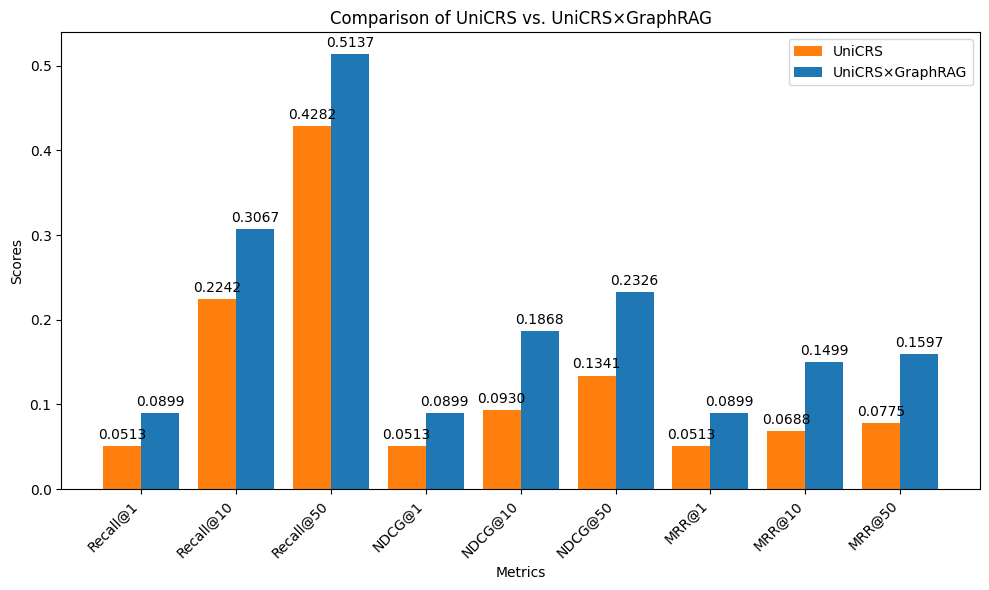

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Metric names
metrics = [
    "Recall@1", "Recall@10", "Recall@50",
    "NDCG@1", "NDCG@10", "NDCG@50",
    "MRR@1", "MRR@10", "MRR@50"
]

# UniCRS scores
uniCRS_scores = [0.0513, 0.2242, 0.4282, 0.0513, 0.0930, 0.1341, 0.0513, 0.0688, 0.0775]

# UniCRS×GraphRAG scores
uniCRSxGraphRAG_scores = [0.0899, 0.3067, 0.5137, 0.0899, 0.1868, 0.2326, 0.0899, 0.1499, 0.1597]

# X-axis locations
x = np.arange(len(metrics))

# Bar width
width = 0.4

# Create figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars
bars1 = ax.bar(x - width/2, uniCRS_scores, width, label='UniCRS', color='#ff7f0e')
bars2 = ax.bar(x + width/2, uniCRSxGraphRAG_scores, width, label='UniCRS×GraphRAG', color='#1f77b4')

# Labels and title
ax.set_xlabel("Metrics")
ax.set_ylabel("Scores")
ax.set_title("Comparison of UniCRS vs. UniCRS×GraphRAG")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha="right")
ax.legend()

# Show values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.4f}', 
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

# Show plot
plt.tight_layout()
plt.show()


/tmp/ipykernel_2368415/1756396663.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df['Model'], y=sorted_df[recall], palette=colors)


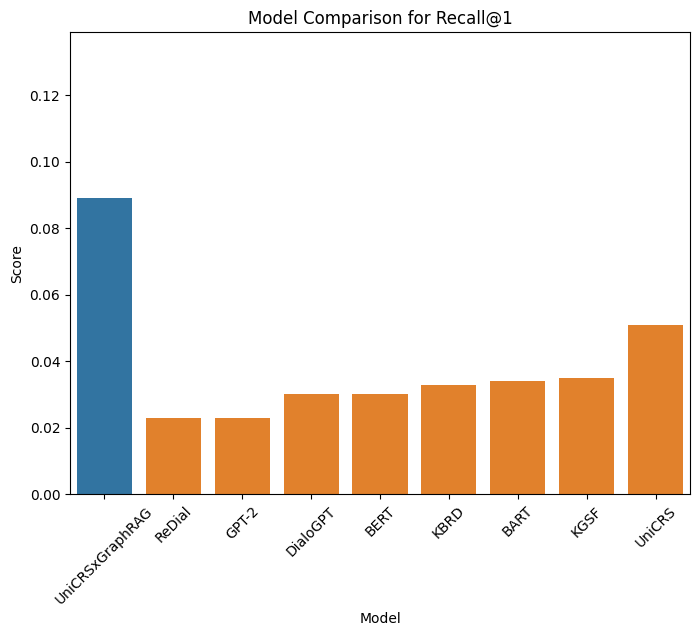

/tmp/ipykernel_2368415/1756396663.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df['Model'], y=sorted_df[recall], palette=colors)


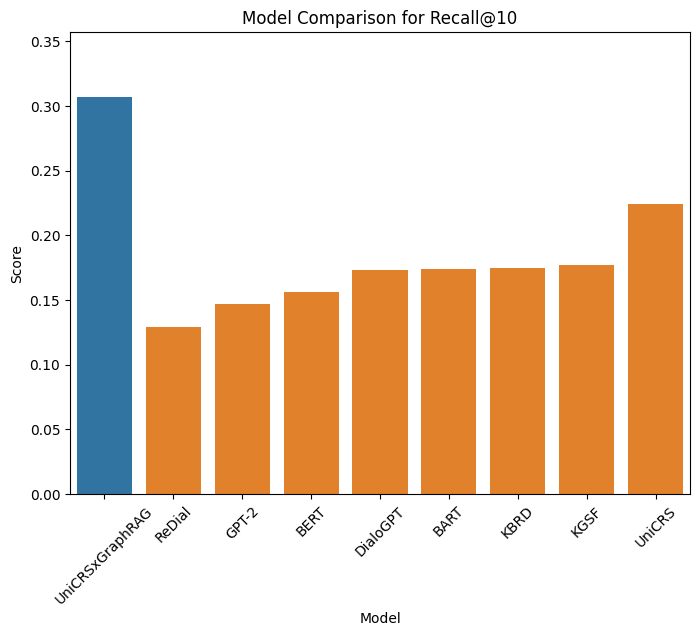

/tmp/ipykernel_2368415/1756396663.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df['Model'], y=sorted_df[recall], palette=colors)


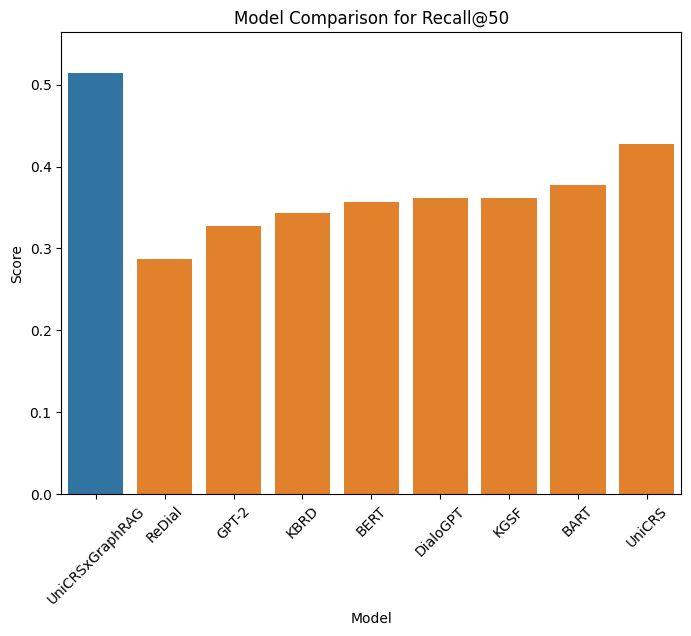

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from the table
data = {
    'Model': ['ReDial', 'KBRD', 'KGSF', 'GPT-2', 'DialoGPT', 'BERT', 'BART', 'UniCRS', 'UniCRSxGraphRAG'],
    'Recall@1': [0.023, 0.033, 0.035, 0.023, 0.030, 0.030, 0.034, 0.051, 0.089],
    'Recall@10': [0.129, 0.175, 0.177, 0.147, 0.173, 0.156, 0.174, 0.224, 0.307],
    'Recall@50': [0.287, 0.343, 0.362, 0.327, 0.361, 0.357, 0.377, 0.428, 0.514]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Define colors
unicrsxgraphrag_color = "#1f77b4"  # Blue
other_models_color = "#ff7f0e"  # Orange

# Iterate over each recall metric and create separate vertical bar plots
recall_metrics = ['Recall@1', 'Recall@10', 'Recall@50']

for recall in recall_metrics:
    plt.figure(figsize=(8, 6))
    
    # Sort models in ascending order (excluding UniCRSxGraphRAG)
    sorted_df = df[df['Model'] != 'UniCRSxGraphRAG'].sort_values(by=recall)
    
    # Place UniCRSxGraphRAG at the start
    sorted_df = pd.concat([df[df['Model'] == 'UniCRSxGraphRAG'], sorted_df])
    
    # Define colors based on model
    colors = [unicrsxgraphrag_color if model == 'UniCRSxGraphRAG' else other_models_color for model in sorted_df['Model']]
    
    # Create vertical bar plot
    sns.barplot(x=sorted_df['Model'], y=sorted_df[recall], palette=colors)
    
    # Plot formatting
    plt.ylabel('Score')
    plt.xlabel('Model')
    plt.title(f'Model Comparison for {recall}')
    
    # Adjust y-axis limit dynamically based on the max value of the recall metric
    plt.ylim(0, max(sorted_df[recall]) + 0.05)
    
    plt.xticks(rotation=45)
    
    plt.show()



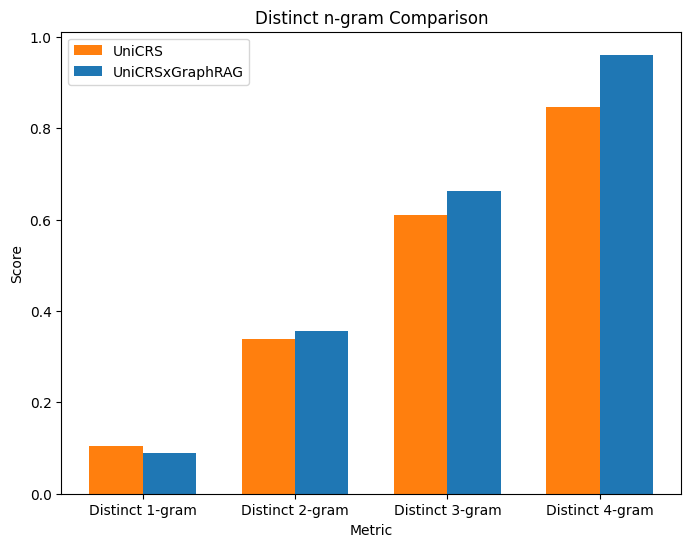

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from the second table
data_distinct = {
    'Metric': ['Distinct 1-gram', 'Distinct 2-gram', 'Distinct 3-gram', 'Distinct 4-gram'],
    'UniCRS': [0.105, 0.339, 0.611, 0.8469],
    'UniCRSxGraphRAG': [0.089, 0.355, 0.663, 0.961]
}

# Convert to DataFrame
df_distinct = pd.DataFrame(data_distinct)

# Define colors
bar_colors = ["#ff7f0e", "#1f77b4"]  # UniCRS (Orange), UniCRSxGraphRAG (Blue)

# Create a bar plot for distinct n-grams
plt.figure(figsize=(8, 6))

bar_width = 0.35
x = range(len(df_distinct['Metric']))

plt.bar(x, df_distinct['UniCRS'], width=bar_width, label='UniCRS', color=bar_colors[0])
plt.bar([i + bar_width for i in x], df_distinct['UniCRSxGraphRAG'], width=bar_width, label='UniCRSxGraphRAG', color=bar_colors[1])

# Plot formatting
plt.ylabel('Score')
plt.xlabel('Metric')
plt.title('Distinct n-gram Comparison')
plt.xticks([i + bar_width / 2 for i in x], df_distinct['Metric'])
plt.legend()
plt.ylim(0, max(df_distinct.max(numeric_only=True)) + 0.05)

plt.show()


/tmp/ipykernel_2391811/4144077789.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df.index, y=sorted_df[metric], palette=colors)


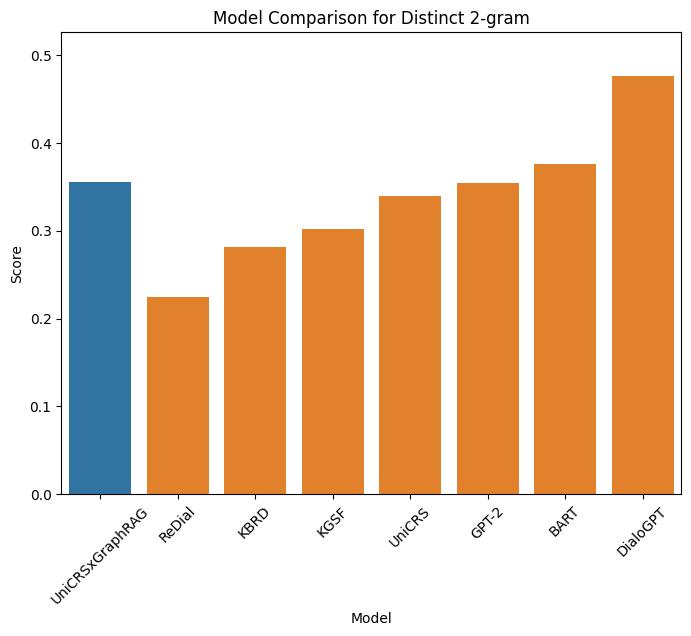

/tmp/ipykernel_2391811/4144077789.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df.index, y=sorted_df[metric], palette=colors)


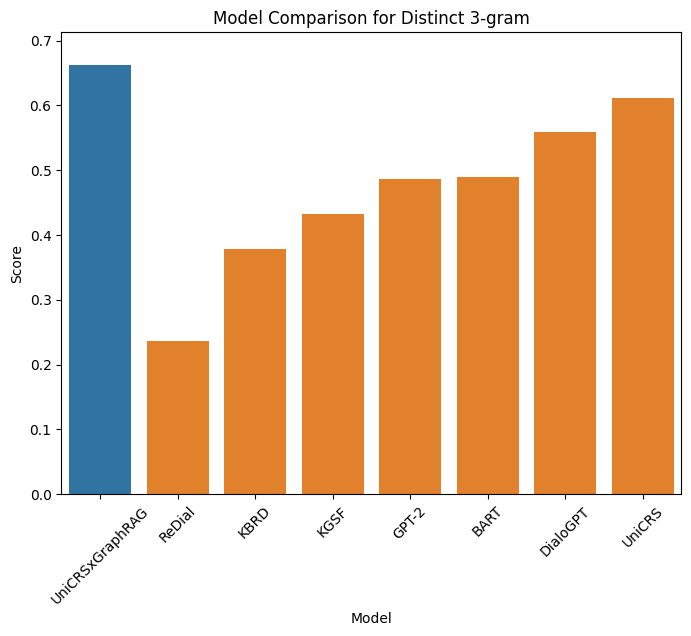

/tmp/ipykernel_2391811/4144077789.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_df.index, y=sorted_df[metric], palette=colors)


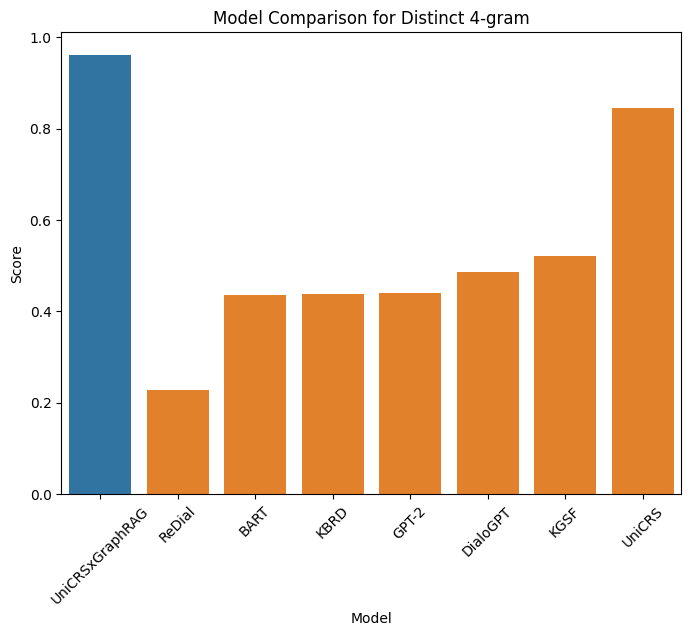

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from the table
models = ['ReDial', 'KBRD', 'KGSF', 'GPT-2', 'DialoGPT', 'BART', 'UniCRS', 'UniCRSxGraphRAG']
metrics = ['Distinct 2-gram', 'Distinct 3-gram', 'Distinct 4-gram']

values = {
    'Distinct 2-gram': [0.225, 0.281, 0.302, 0.354, 0.476, 0.376, 0.339, 0.355],
    'Distinct 3-gram': [0.236, 0.379, 0.433, 0.486, 0.559, 0.490, 0.611, 0.663],
    'Distinct 4-gram': [0.228, 0.439, 0.521, 0.441, 0.486, 0.435, 0.846, 0.961]
}

# Convert to DataFrame
df = pd.DataFrame(values, index=models)

# Define colors
unicrsxgraphrag_color = "#1f77b4"  # Blue
other_models_color = "#ff7f0e"  # Orange

for metric in metrics:
    plt.figure(figsize=(8, 6))
    
    # Sort models (UniCRSxGraphRAG first, rest sorted by score)
    sorted_df = df.sort_values(by=metric)
    sorted_df = pd.concat([df.loc[['UniCRSxGraphRAG']], sorted_df.drop('UniCRSxGraphRAG')])
    
    colors = [unicrsxgraphrag_color if model == 'UniCRSxGraphRAG' else other_models_color for model in sorted_df.index]
    
    sns.barplot(x=sorted_df.index, y=sorted_df[metric], palette=colors)
    
    plt.ylabel('Score')
    plt.xlabel('Model')
    plt.title(f'Model Comparison for {metric}')
    plt.ylim(0, max(sorted_df[metric]) + 0.05)
    plt.xticks(rotation=45)
    
    plt.show()


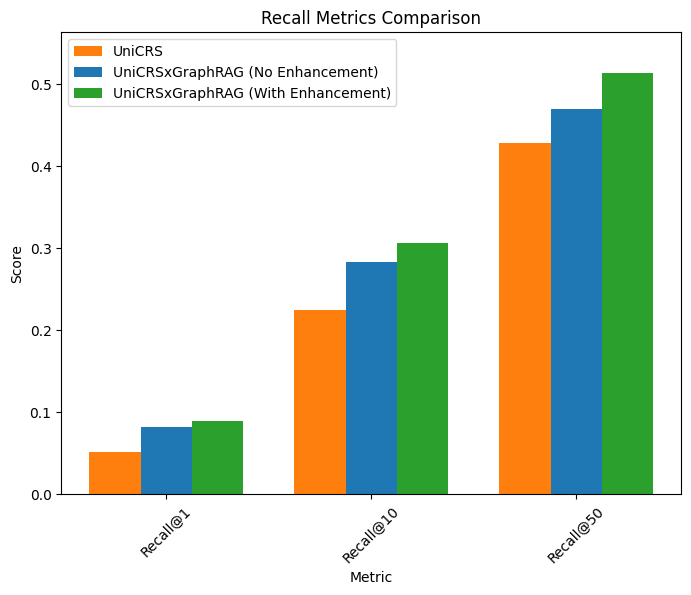

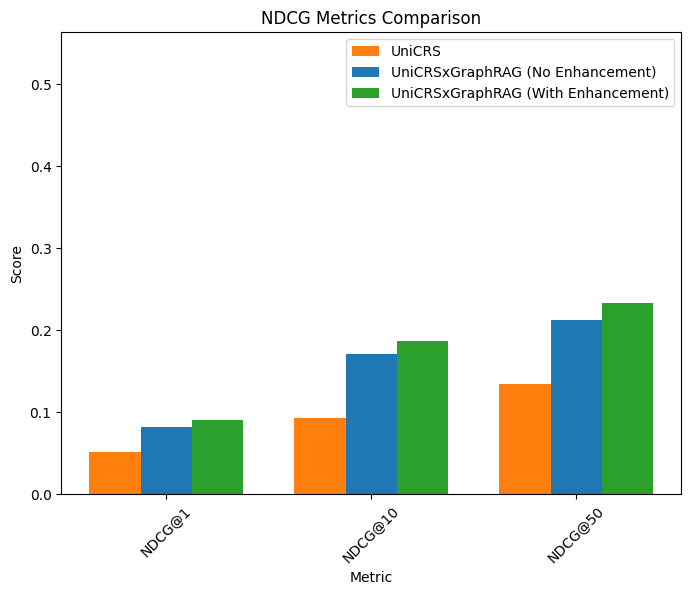

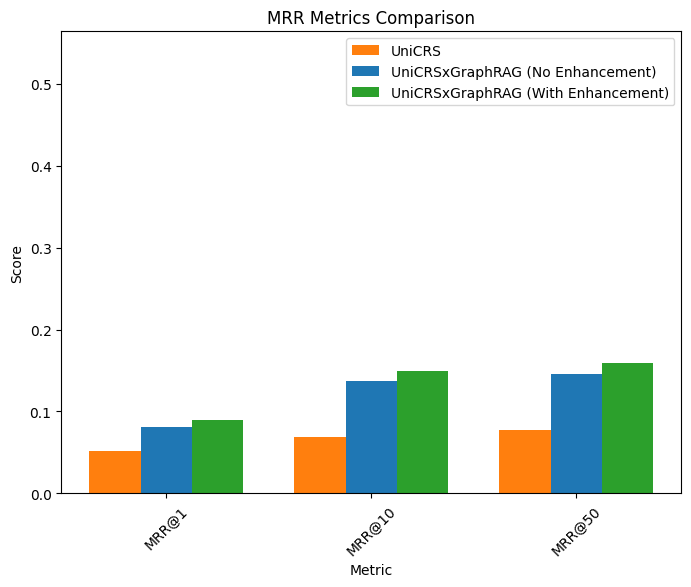

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the table
metrics = ['Recall@1', 'Recall@10', 'Recall@50', 'NDCG@1', 'NDCG@10', 'NDCG@50', 'MRR@1', 'MRR@10', 'MRR@50']
unicrs = [0.0513, 0.2242, 0.4282, 0.0513, 0.0930, 0.1341, 0.0513, 0.0688, 0.0775]
unicrsx_no_enhance = [0.0816, 0.2833, 0.4695, 0.0816, 0.1710, 0.2124, 0.0816, 0.1366, 0.1455]
unicrsx_enhance = [0.0899, 0.3067, 0.5137, 0.0899, 0.1868, 0.2326, 0.0899, 0.1499, 0.1597]

# Separate the metrics into Recall, NDCG, and MRR
categories = {'Recall': (0, 3), 'NDCG': (3, 6), 'MRR': (6, 9)}
labels = ['UniCRS', 'UniCRSxGraphRAG (No Enhancement)', 'UniCRSxGraphRAG (With Enhancement)']
colors = ['#ff7f0e', '#1f77b4', '#2ca02c']  # Orange, Blue, Green

# Plot each category separately
for category, (start, end) in categories.items():
    x = np.arange(end - start)  # Position of bars
    width = 0.25  # Bar width
    
    plt.figure(figsize=(8, 6))
    plt.bar(x - width, unicrs[start:end], width=width, label=labels[0], color=colors[0])
    plt.bar(x, unicrsx_no_enhance[start:end], width=width, label=labels[1], color=colors[1])
    plt.bar(x + width, unicrsx_enhance[start:end], width=width, label=labels[2], color=colors[2])
    
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.title(f'{category} Metrics Comparison')
    plt.xticks(x, metrics[start:end], rotation=45)
    plt.legend()
    plt.ylim(0, max(unicrsx_enhance) + 0.05)
    plt.show()
